In [1]:
!pip install earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.5 MB/s eta 0:00:00


In [2]:
import ee
ee.Authenticate()
ee.Initialize(project='handy-post-458213-t7')

In [3]:
roi = ee.Geometry.Polygon([
    [
        [75.619846, 16.287265],
        [75.61976, 16.287749],
        [75.623441, 16.287816],
        [75.623447, 16.287322],
        [75.619846, 16.287265]
    ]
])

In [4]:
dataset = (ee.ImageCollection('COPERNICUS/S2_SR')
           .filterBounds(roi)
           .filterDate('2023-01-01', '2024-12-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


In [5]:
def addEVI(image):
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }
    ).rename('EVI')

    return image.addBands(evi)

In [6]:
evi_collection = dataset.map(addEVI)

In [7]:
def extract_evi(image):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10
    )

    return ee.Feature(None, {
        'date': image.date().format('YYYY-MM-dd'),
        'EVI': stats.get('EVI')
    })

evi_features = evi_collection.map(extract_evi)

In [8]:
import pandas as pd

data = evi_features.getInfo()

dates = []
values = []

for feature in data['features']:
    dates.append(feature['properties']['date'])
    values.append(feature['properties']['EVI'])

df = pd.DataFrame({
    'Date': dates,
    'EVI': values
})

df.head()

,Date,EVI
0,2023-01-01,0.710623
1,2023-01-06,0.467976
2,2023-01-11,0.494013
3,2023-01-16,0.458665
4,2023-01-21,0.516564


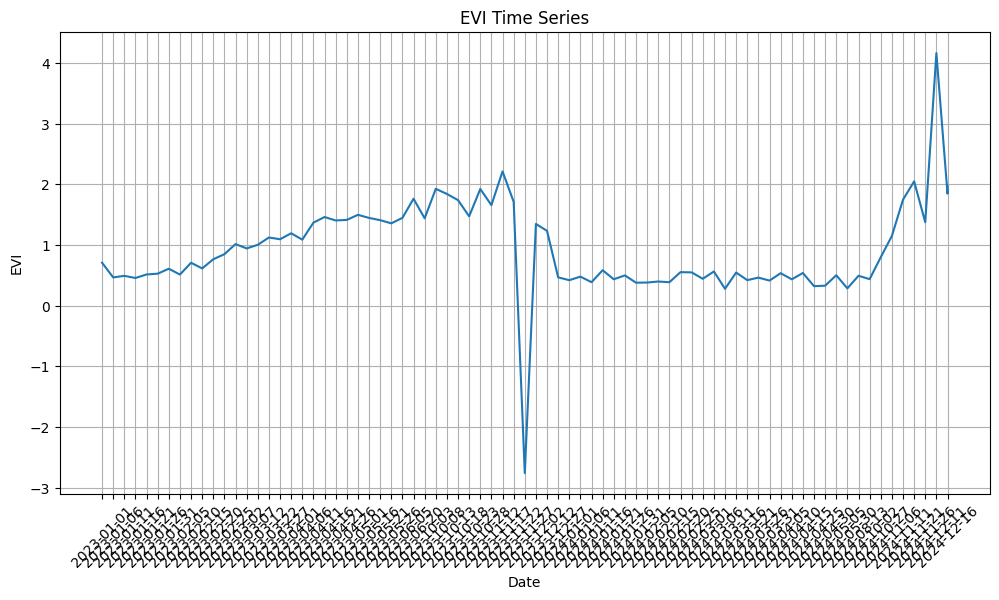

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['EVI'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('EVI')
plt.title('EVI Time Series')
plt.grid()
plt.show()